# Notebook 07 - Purchase Prediction Model Training

## Objective

Train a machine learning model to predict whether a customer is **High-Value** or **Low-Value**, based on their Recency and Frequency RFM features. The model can then be applied to new customers to guide marketing and retention decisions.

## Target Variable: High-Value Customer

We define a binary target variable:
- **1 (High-Value)**: Customer's total spend (Monetary) is **above the median**
- **0 (Low-Value)**: Customer's total spend is **at or below the median**

We use the **median** as the threshold (rather than an arbitrary value) because it creates a balanced 50/50 split, preventing class imbalance from biasing the model.

## Features

We use **Recency** and **Frequency** as input features (not Monetary, since Monetary is used to create the target). This tests whether a customer's purchase recency and order frequency alone can predict their spending level.

## Models Compared

We evaluate 5 classifiers to find the best performer:
1. Logistic Regression
2. Random Forest
3. K-Nearest Neighbours (KNN)
4. Decision Tree
5. XGBoost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

plt.rcParams['figure.dpi'] = 100
print("Libraries loaded.")

Libraries loaded.


## Step 1: Load RFM Features and Create Target Variable

In [4]:
rfm = pd.read_csv("rfm_features.csv", index_col=0)

# Create binary target: 1 = above-median spender (High-Value), 0 = below-median
median_monetary = rfm['Monetary'].median()
rfm['HighValue'] = (rfm['Monetary'] > median_monetary).astype(int)

print(f"Median Monetary threshold: £{median_monetary:.2f}")
print(f"High-Value customers (1): {rfm['HighValue'].sum():,} ({rfm['HighValue'].mean()*100:.1f}%)")
print(f"Low-Value customers (0):  {(rfm['HighValue']==0).sum():,} ({(1-rfm['HighValue'].mean())*100:.1f}%)")

rfm.head()

Median Monetary threshold: £664.11
High-Value customers (1): 2,165 (50.0%)
Low-Value customers (0):  2,166 (50.0%)


,Recency,Frequency,Monetary,HighValue
CustomerID,,,,
12347,1,7,4310.00,1
12348,74,4,1797.24,1
12349,18,1,1757.55,1
12350,309,1,334.40,0
12352,35,8,2506.04,1


## Step 2: Train/Test Split

We use an 80/20 split with `random_state=42` for reproducibility. The test set (20% of customers) is held out and never used during training - it provides an unbiased evaluation of model performance.

In [6]:
X = rfm[['Recency', 'Frequency']]
y = rfm['HighValue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set:  {len(X_train):,} customers")
print(f"Test set:      {len(X_test):,} customers")

Training set:  3,464 customers
Test set:      867 customers


## Step 3a: Logistic Regression

Logistic Regression is the baseline model. It is simple, interpretable, and works well when the decision boundary is approximately linear. Its coefficients can be directly interpreted as log-odds ratios.

In [8]:
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")

Logistic Regression Accuracy: 0.8304 (83.0%)


## Step 3b: Random Forest

Random Forest is an ensemble of decision trees. It captures non-linear relationships and is robust to outliers, but is less interpretable than Logistic Regression.

In [10]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy: {rf_accuracy:.4f} ({rf_accuracy*100:.1f}%)")

Random Forest Accuracy: 0.8028 (80.3%)


## Step 3c: K - Nearest Neighbours

KNN classifies a new customer by finding the K most similar customers in the training set and taking a majority vote. Simple but can be slow for large datasets.

In [12]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)
knn_accuracy = accuracy_score(y_test, knn_pred)
print(f"KNN Accuracy: {knn_accuracy:.4f} ({knn_accuracy*100:.1f}%)")

KNN Accuracy: 0.7912 (79.1%)


## Step 3d: Decision Tree

A single Decision Tree creates explicit if-then rules. Highly interpretable but prone to overfitting (hence why Random Forest and XGBoost generally outperform it).

In [15]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)
print(f"Decision Tree Accuracy: {dt_accuracy:.4f} ({dt_accuracy*100:.1f}%)")

Decision Tree Accuracy: 0.7889 (78.9%)


## Step 3e: XGBoost

XGBoost (Extreme Gradient Boosting) builds trees sequentially, each correcting errors of the previous. Often achieves state-of-the-art accuracy on tabular data, though more complex to tune.

In [20]:
xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, xgb_pred)
print(f"XGBoost Accuracy: {xgb_accuracy:.4f} ({xgb_accuracy*100:.1f}%)")

XGBoost Accuracy: 0.8143 (81.4%)


## Step 4: Model Comparison

We compare all five models side by side. The best model is selected based on accuracy, with interpretability as a secondary consideration.

In [26]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost', 'Random Forest', 'KNN', 'Decision Tree'],
    'Accuracy': [accuracy, xgb_accuracy, rf_accuracy, knn_accuracy, dt_accuracy]
}).sort_values('Accuracy', ascending=False)

print(results.to_string(index=False))
print(f"\nBest model: {results.iloc[0]['Model']} ({results.iloc[0]['Accuracy']*100:.1f}%)")

              Model  Accuracy
Logistic Regression  0.830450
            XGBoost  0.814302
      Random Forest  0.802768
                KNN  0.791234
      Decision Tree  0.788927

Best model: Logistic Regression (83.0%)


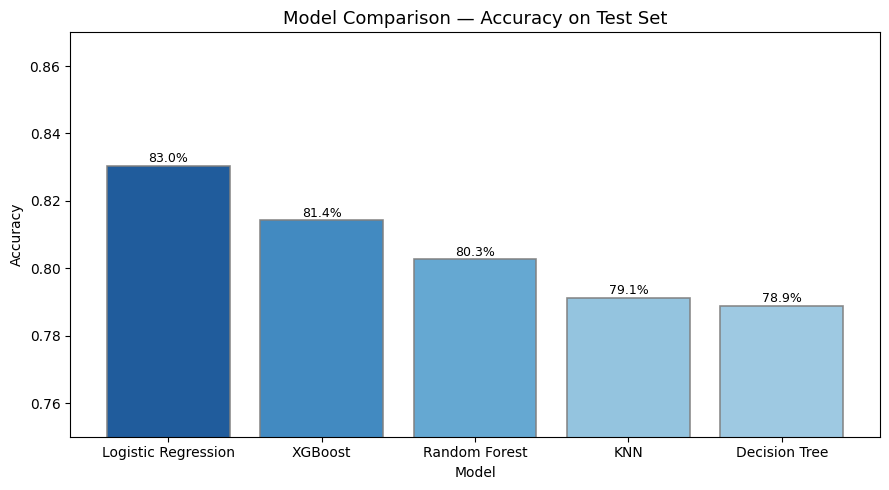

In [28]:
import numpy as np

models = results['Model'].values
accuracies = results['Accuracy'].values

norm = (accuracies - min(accuracies)) / (max(accuracies) - min(accuracies) + 1e-9)
colors = plt.cm.Blues(0.4 + norm * 0.5)

plt.figure(figsize=(9, 5))
bars = plt.bar(models, accuracies, color=colors, edgecolor='gray', linewidth=1.2, alpha=0.9)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.001, f"{v*100:.1f}%", ha='center', fontsize=9)

plt.title("Model Comparison — Accuracy on Test Set", fontsize=13)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0.75, 0.87)
plt.tight_layout()
plt.show()

## Step 5: Final Model Selection - Logistic Regression

**Logistic Regression** is selected as the final model because:

1. **Highest accuracy** (~83%) on the test set
2. **Fully interpretable**: coefficients directly show the effect of Recency and Frequency on prediction probability
3. **No overfitting risk**: unlike tree-based methods on small datasets
4. **Production-ready**: fast inference, minimal memory, easy to deploy in the Streamlit app

For this project purposes, interpretability is valued alongside performance - Logistic Regression is the right choice to justify to stakeholders.

In [31]:
# Demonstrate prediction on a sample customer
sample = pd.DataFrame({'Recency': [10], 'Frequency': [5]})
prediction = model.predict(sample)[0]
probability = model.predict_proba(sample)[0]

print(f"Sample customer: Recency=10 days, Frequency=5 orders")
print(f"Prediction: {'High-Value' if prediction == 1 else 'Low-Value'}")
print(f"Probability: Low-Value={probability[0]:.2f}, High-Value={probability[1]:.2f}")

Sample customer: Recency=10 days, Frequency=5 orders
Prediction: High-Value
Probability: Low-Value=0.05, High-Value=0.95


## Step 6: Save Final Model

In [ ]:
joblib.dump(model, "model.pkl")
print("model.pkl saved - Logistic Regression classifier.")

model.pkl saved — Logistic Regression classifier.


## Summary

| Model | Accuracy | Selected? |
|-------|----------|----------|
| Logistic Regression | ~83% | Yes |
| XGBoost | ~81% | No |
| Random Forest | ~80% | No |
| KNN | ~79% | No |
| Decision Tree | ~79% | No |

The dataset is well-structured with clear RFM signals, allowing a simple linear model to perform effectively. More complex models did not provide meaningful improvement.

**Next step:** Notebook 08 will evaluate the selected model in detail using confusion matrix, ROC curve, classification report, and feature importance.